<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


# Project for Statistics for Data Science with Python

# Overview

**Project Scenario**: You are a Data Scientist with a housing agency in Boston MA, you have been given access to a previous dataset on housing prices derived from the U.S. Census Service to present insights to higher management. Based on your experience in Statistics, what information can you provide them to help with making an informed decision? Upper management will like to get some insight into the following.

- Is there a significant difference in the median value of houses bounded by the Charles river or not?

- Is there a difference in median values of houses of each proportion of owner-occupied units built before 1940?

- Can we conclude that there is no relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town?

- What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner-occupied homes?

Using the appropriate graphs and charts, generate basic statistics and visualizations that you think will be useful for the upper management to give them important insight given the question they are asking, in your graphs, include an explanation of each statistic.

#### Import the required libraries we need for the lab.


In [21]:
%pip install seaborn

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [23]:
import io
from pyodide.http import open_url

# 1. We use the environment's special function to open the URL
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
compressed_file = open_url(url)

# 2. Now pandas can read the contents without problems
boston_df = pd.read_csv(io.StringIO(compressed_file.read()))

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [24]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [25]:
boston_df.dtypes

Unnamed: 0      int64
CRIM          float64
ZN            float64
INDUS         float64
CHAS          float64
NOX           float64
RM            float64
AGE           float64
DIS           float64
RAD           float64
TAX           float64
PTRATIO       float64
LSTAT         float64
MEDV          float64
dtype: object

In [26]:
boston_df.isnull().sum()

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

In [27]:
boston_df.duplicated().sum()

0

In [28]:
boston_df.corr()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,0.258465,-0.226604
CRIM,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626


## Visualization

### 1. Display descriptive statistics of the dataset

In [29]:
boston_df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


### 2. Create a boxplot for MEDV (Median value of owner-occupied homes)

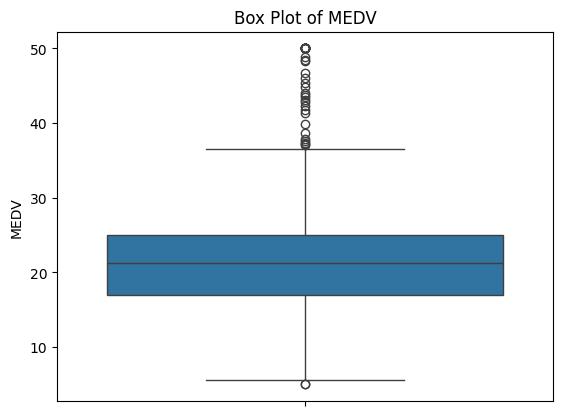

In [30]:
ax = sns.boxplot(y='MEDV', data=boston_df)
plt.title("Box Plot of MEDV");

There are some outliers

### 3. Create a bar plot for CHAS (Charles River dummy variable)

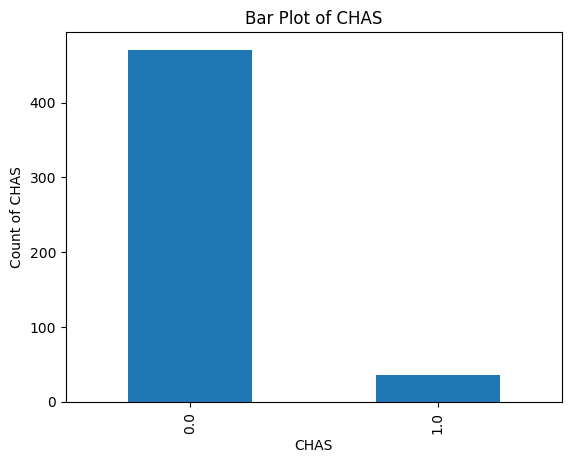

In [35]:
boston_df['CHAS'].value_counts().plot(kind='bar')
plt.ylabel("Count of CHAS")
plt.title("Bar Plot of CHAS");

Numbers of tract bounds river are much smaller than those not

### 4. Discretize AGE into three groups and create a boxplot of MEDV versus AGE groups

In [43]:
boston_df.loc[(boston_df['AGE'] <= 35), 'AGE_GROUP'] = 'Younger' # '35 years and younger'
boston_df.loc[(boston_df['AGE'] > 35)&(boston_df['AGE'] < 70), 'AGE_GROUP'] = 'Middle' # 'between 35 and 70 years'
boston_df.loc[(boston_df['AGE'] >= 70), 'AGE_GROUP'] = 'Older' # '70 years and older'

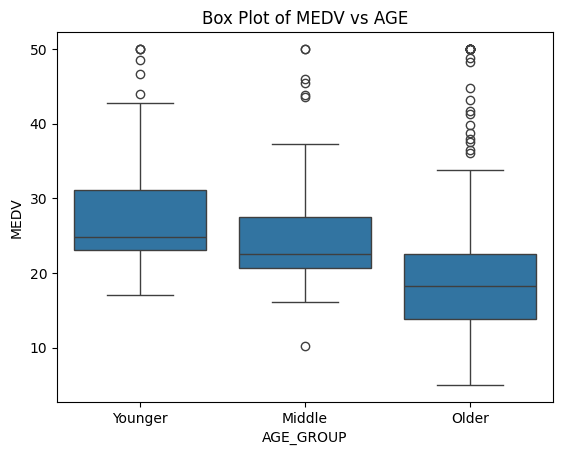

In [47]:
ax = sns.boxplot(x='AGE_GROUP', y='MEDV', order=['Younger', 'Middle', 'Older'], data=boston_df)
plt.title("Box Plot of MEDV vs AGE");

There is a declining trend of median value of owner-occupied homes for increasing age

### 5. Create a scatter plot showing the relationship between NOX (nitric oxide concentrations) and INDUS (non-retail business acres)

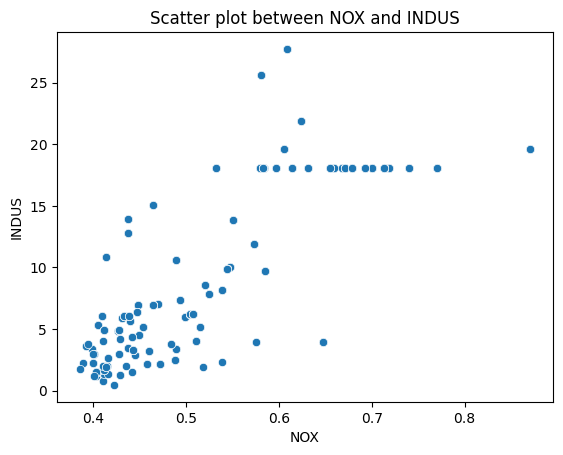

In [48]:
ax = sns.scatterplot(x='NOX', y='INDUS', data=boston_df)
plt.title("Scatter plot between NOX and INDUS");

There is a positive correlation between nitric oxides concentration and proportion of non-retail business acres per town

### 6. Create a histogram for PTRATIO (pupil-teacher ratio)

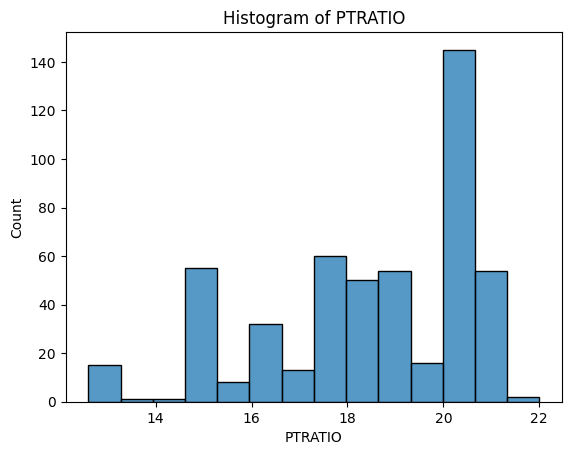

In [57]:
ax = sns.histplot(x='PTRATIO', data=boston_df)
plt.title("Histogram of PTRATIO");

The majority of tracts have a high pupil-to-teacher ratio, peaking sharply between 20 and 21

## Hypothesis Analysis

### 1. Use Levene’s test to check if the variances of MEDV for homes bounded by the Charles River (CHAS = 1) and those not bounded (CHAS = 0) are equal

State the hypothesis

* $H_0$: The variances of MEDV are the same for both groups
* $H_1$: The variances of MEDV differ between the groups

In [76]:
scipy.stats.levene(boston_df[boston_df['CHAS'] == 0]['MEDV'],
                   boston_df[boston_df['CHAS'] == 1]['MEDV'], center='mean')

LeveneResult(statistic=8.75190489604598, pvalue=0.003238119367639829)

**Conclusion**: Since the p-value is less than 0.05 we cannot assume equality of variance.

### 2. Perform a T-test to determine if there is a significant difference in MEDV between homes bounded and not bounded by the Charles River

State the hypothesis

* $H_0$: No difference in mean value of houses bounded by the Charles river
* $H_1$: There is a significant difference in mean value of houses bounded by the Charles river

In [77]:
scipy.stats.ttest_ind(boston_df[boston_df['CHAS'] == 0]['MEDV'],
                   boston_df[boston_df['CHAS'] == 1]['MEDV'], equal_var = False)

TtestResult(statistic=-3.113291312794837, pvalue=0.003567170098137517, df=36.876408797611994)

**Conclusion**: Since the p-value is less than 0.05 we reject null hypothesis. So there is a significant difference in mean value of houses bounded by the Charles river.

### 3. Conduct an ANOVA test to compare MEDV among the three AGE groups created earlier

State the hypothesis

* $H_0$: The average MEDV is the same for all three age groups
* $H_1$: At least one age group has a different average MEDV

In [78]:
younger_medv = boston_df[boston_df['AGE_GROUP'] == 'Younger']['MEDV']
middle_medv = boston_df[boston_df['AGE_GROUP'] == 'Middle']['MEDV']
older_medv = boston_df[boston_df['AGE_GROUP'] == 'Older']['MEDV']

In [80]:
f_statistic, p_value = scipy.stats.f_oneway(younger_medv, middle_medv, older_medv)
print("F_Statistic: {0}, P-Value: {1}".format(f_statistic,p_value))

F_Statistic: 36.40764999196599, P-Value: 1.7105011022702984e-15


**Conclusion**: Reject the null hypothesis since the p-value is less than 0.05. There is significant evidence that at least one age group has a different average MEDV.

### 4. Perform a Pearson correlation test to assess the relationship between NOX and INDUS

State the hypothesis

* $H_0$: No relationship between Nitric oxide concentrations and proportion of non-retail business acres per town
* $H_1$: There is relationship

In [85]:
scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

PearsonRResult(statistic=0.7636514469209192, pvalue=7.913361061210442e-98)

**Conclusion**: p < 0.05 there is evidence of correlation between Nitric oxide concentrations (NOX) and proportion of non-retail business acres per town (INDUS).

### 5. Fit a simple linear regression model to evaluate the impact of DIS (distance to employment centres) on MEDV. Report and interpret the regression results

State the hypothesis

* $H_0$: No impact of DIS on MEDV (The slope is equal to zero)
* $H_1$: There is relationship (The slope is non-zero)

In [86]:
## X is the input variables (or independent variables)
X = boston_df['DIS']
## y is the target/dependent variable
y = boston_df['MEDV']
## add an intercept (beta_0) to our model
X = sm.add_constant(X) 

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.21e-08
Time:                        21:05:29   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Conclusion**: Since p < 0.05, there is statistical evidence that the weighted distance to the five Boston employment centres (DIS) impacts the median value of houses (MEDV). R-square is 0.062, R will be √0.062, correlation coefficient is 0.25 (close to 0). There is a weak positive correlation between the weighted distance to the five Boston employment centres (DIS) and the median value of houses (MEDV).